# Obesity Risk Classification Project

In this project, supervised classification algorithms are used to predict obesity levels associated with cardiovascular health risks. Success is assessed based on the overall Accuracy Score.

<img src='https://themedicalbiochemistrypage.org/wp-content/uploads/2020/05/obesity-title-image.jpg' width='750'>

In [1]:
#Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time
import warnings
warnings.filterwarnings('ignore')

# EDA

In [3]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [4]:
train_df.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [5]:
train_df.tail()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
20753,20753,Male,25.137087,1.766626,114.187096,yes,yes,2.919584,3.000000,Sometimes,no,2.151809,no,1.330519,0.196680,Sometimes,Public_Transportation,Obesity_Type_II
20754,20754,Male,18.000000,1.710000,50.000000,no,yes,3.000000,4.000000,Frequently,no,1.000000,no,2.000000,1.000000,Sometimes,Public_Transportation,Insufficient_Weight
20755,20755,Male,20.101026,1.819557,105.580491,yes,yes,2.407817,3.000000,Sometimes,no,2.000000,no,1.158040,1.198439,no,Public_Transportation,Obesity_Type_II
20756,20756,Male,33.852953,1.700000,83.520113,yes,yes,2.671238,1.971472,Sometimes,no,2.144838,no,0.000000,0.973834,no,Automobile,Overweight_Level_II
20757,20757,Male,26.680376,1.816547,118.134898,yes,yes,3.000000,3.000000,Sometimes,no,2.003563,no,0.684487,0.713823,Sometimes,Public_Transportation,Obesity_Type_II


In [6]:
train_df.shape

(20758, 18)

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

In [8]:
train_df.isnull().sum()

id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [9]:
train_df.describe()

,id,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,20758.00000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,10378.50000,23.841804,1.700245,87.887768,2.445908,2.761332,2.029418,0.981747,0.616756
std,5992.46278,5.688072,0.087312,26.379443,0.533218,0.705375,0.608467,0.838302,0.602113
min,0.00000,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,5189.25000,20.000000,1.631856,66.000000,2.000000,3.000000,1.792022,0.008013,0.000000
50%,10378.50000,22.815416,1.700000,84.064875,2.393837,3.000000,2.000000,1.000000,0.573887
75%,15567.75000,26.000000,1.762887,111.600553,3.000000,3.000000,2.549617,1.587406,1.000000
max,20757.00000,61.000000,1.975663,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000


In [11]:
train_df.corr(numeric_only=True)

,id,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
id,1.000000,0.007634,0.012041,0.014020,0.002098,-0.000332,0.007917,0.016719,0.007667
Age,0.007634,1.000000,-0.011713,0.283381,0.034414,-0.048479,-0.016325,-0.192259,-0.296154
Height,0.012041,-0.011713,1.000000,0.416677,-0.071546,0.191383,0.183706,0.295278,0.076433
Weight,0.014020,0.283381,0.416677,1.000000,0.245682,0.095947,0.317914,-0.084845,-0.086471
FCVC,0.002098,0.034414,-0.071546,0.245682,1.000000,0.113349,0.101299,-0.089822,-0.147843
NCP,-0.000332,-0.048479,0.191383,0.095947,0.113349,1.000000,0.080949,0.100871,0.067459
CH2O,0.007917,-0.016325,0.183706,0.317914,0.101299,0.080949,1.000000,0.082932,-0.010654
FAF,0.016719,-0.192259,0.295278,-0.084845,-0.089822,0.100871,0.082932,1.000000,0.021213
TUE,0.007667,-0.296154,0.076433,-0.086471,-0.147843,0.067459,-0.010654,0.021213,1.000000


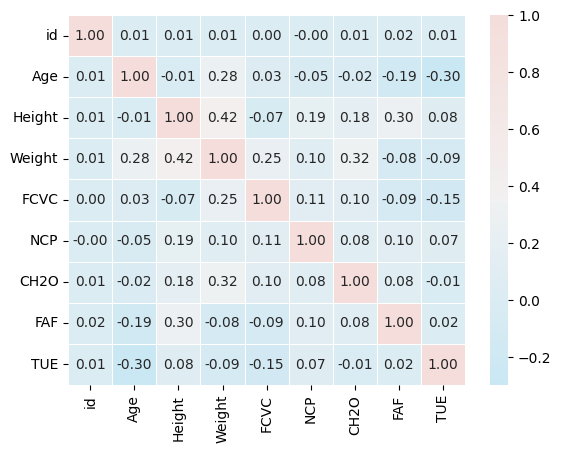

In [14]:
cmap = sns.diverging_palette(220, 20, as_cmap=True, s=60, l=90)
sns.heatmap(train_df.corr(numeric_only=True), annot=True, linewidths=0.5, fmt=".2f", cmap=cmap);

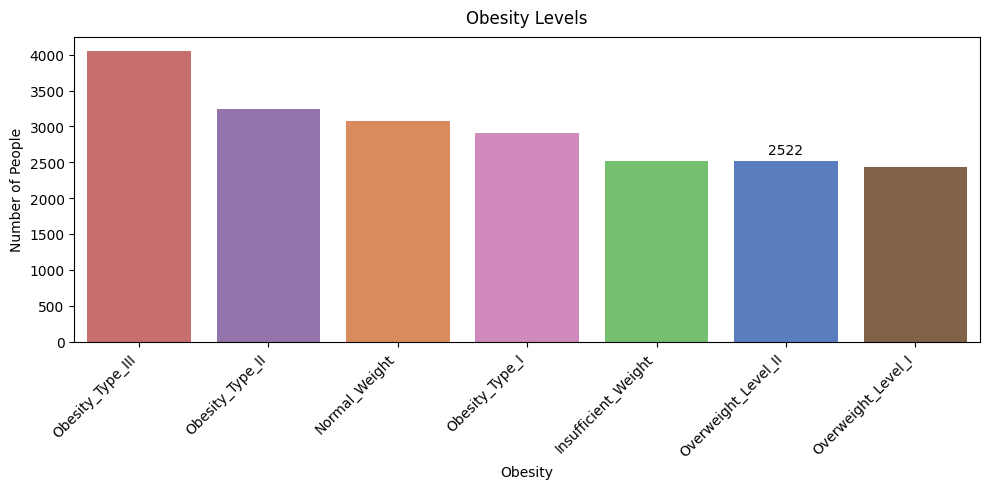

In [15]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=train_df,
    x='NObeyesdad',
    order=train_df['NObeyesdad'].value_counts().index,
    palette='muted',
    hue='NObeyesdad',
    legend=False
)

plt.title('Obesity Levels', fontsize=12, pad=10)
plt.xlabel('Obesity')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right')
ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.show()

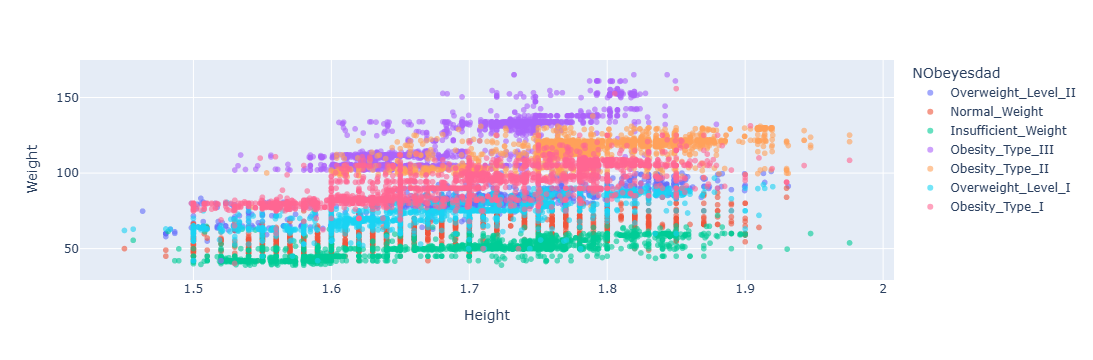

In [16]:
import plotly.express as px

px.scatter(train_df, x='Height', y='Weight', color='NObeyesdad', opacity=0.6)

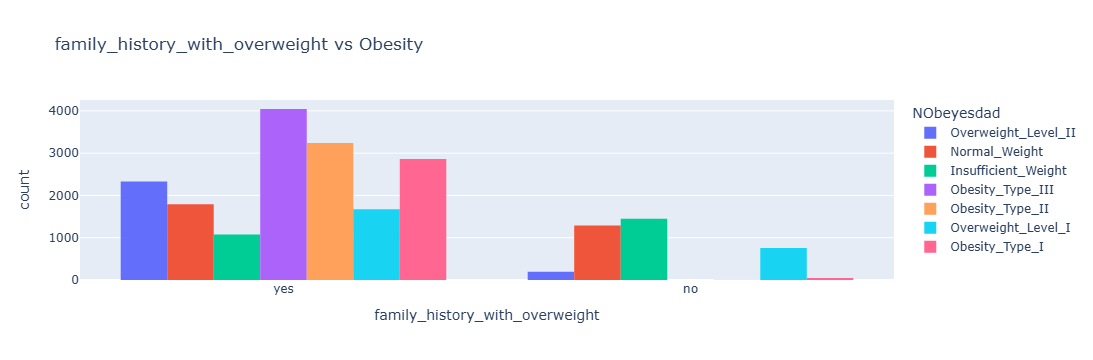

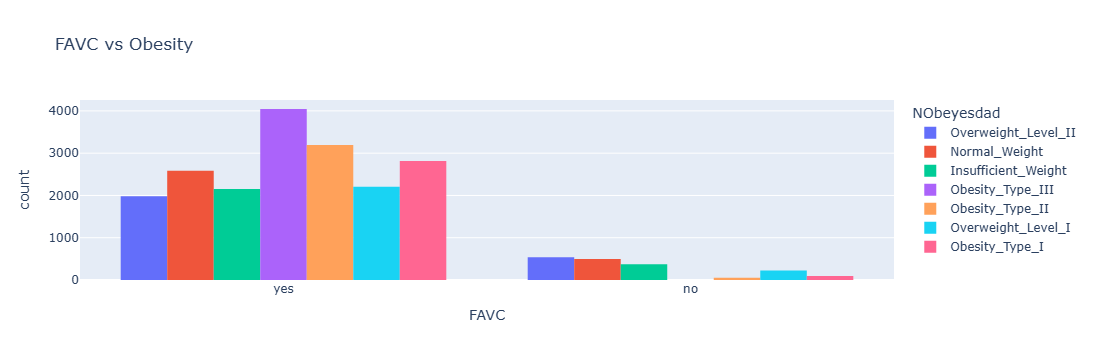

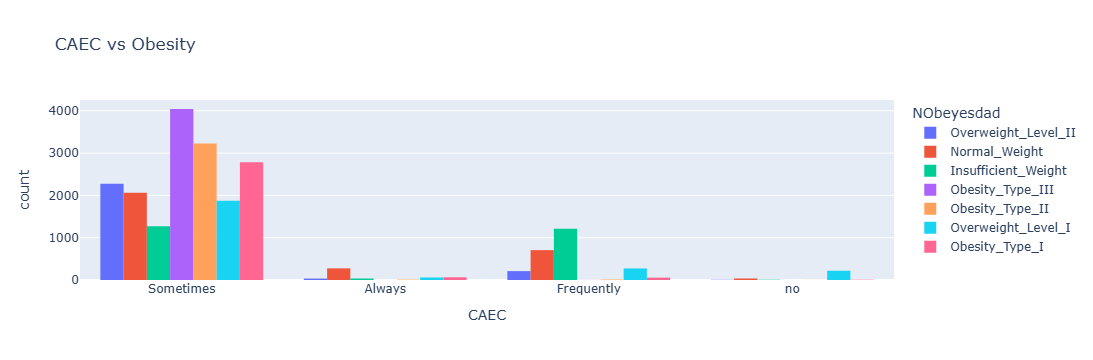

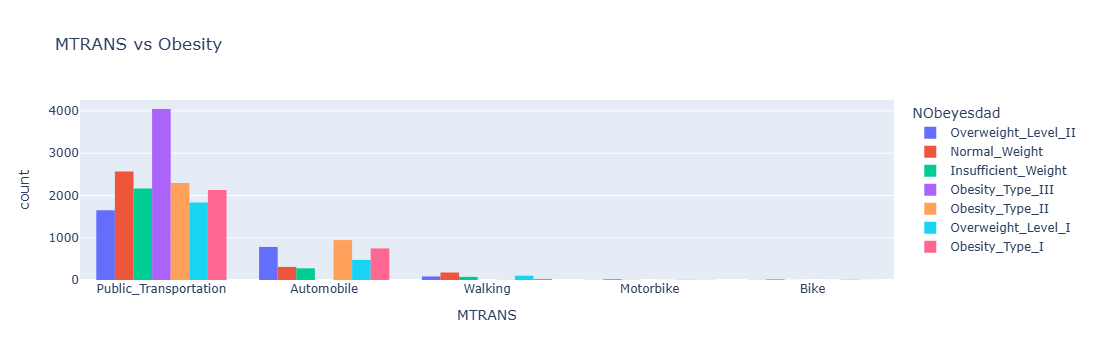

In [19]:
import plotly.express as px

cat_cols = ['family_history_with_overweight', 'FAVC', 'CAEC', 'MTRANS']

for col in cat_cols:
    px.histogram(
        train_df, x=col, color='NObeyesdad', 
        barmode='group', title=f'{col} vs Obesity'
    ).show()

### Feature Engineering

In [20]:
df = pd.concat([train_df, test_df], keys=[1, 0], names=['is_train', None]).reset_index(level=0)

In [21]:
# BMI
df['BMI'] = df['Weight'] / (df['Height'] ** 2)
df['BMI_2'] = df['BMI'] ** 2

# Age & Age Groups
df['Age'] = df['Age'].round().astype(int)
df['IsYoung'] = (df['Age'] < 25).astype(int)
df['IsAging'] = df['Age'].between(25, 39).astype(int)
df['IsOld'] = (df['Age'] >= 40).astype(int)

In [22]:
df['Family_BMI_Interaction'] = df['family_history_with_overweight'].astype(str) + '_' + (df['BMI'] > 25).astype(str)
df['Gender_Age_Interaction'] = df['Gender'].astype(str) + '_' + (df['Age'] > 30).astype(str)

### Data Process

In [23]:
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS',
                   'Family_BMI_Interaction', 'Gender_Age_Interaction']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [24]:
integer_cols = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for col in integer_cols:
    df[col] = df[col].round().astype(int)

In [25]:
train = df[df['is_train'] == 1].drop(['is_train', 'id'], axis=1)
test = df[df['is_train'] == 0].drop(['is_train', 'id', 'NObeyesdad'], axis=1)

In [26]:
x = train.drop('NObeyesdad', axis=1)
y = train['NObeyesdad']
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

In [27]:
target_mapping = dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))
target_mapping

{'Insufficient_Weight': np.int64(0),
 'Normal_Weight': np.int64(1),
 'Obesity_Type_I': np.int64(2),
 'Obesity_Type_II': np.int64(3),
 'Obesity_Type_III': np.int64(4),
 'Overweight_Level_I': np.int64(5),
 'Overweight_Level_II': np.int64(6)}

In [28]:
inv_target_mapping = {v: k for k, v in target_mapping.items()}

In [29]:
X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

### Modeling

In [35]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb = GradientBoostingClassifier()
kn = KNeighborsClassifier()
ab = AdaBoostClassifier()
mn = MultinomialNB()

def algo_test(x, y):
    models = [b, l, d, r, gb, kn, ab, mn]
    names = [
        "BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
        "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
        "AdaBoostClassifier", "MultinomialNB"
    ]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl = []

    print("Data ready, testing models...")
    for model in models:
        print(f"Training {model.__class__.__name__}...")
        model = model.fit(x_train, y_train)
        predictions = model.predict(x_test)
        mdl.append(model)
        
        accuracy.append(accuracy_score(y_test, predictions))
        precision.append(precision_score(y_test, predictions, average="micro"))
        recall.append(recall_score(y_test, predictions, average="micro"))
        f1.append(f1_score(y_test, predictions, average="micro"))
        print(confusion_matrix(y_test, predictions))

    print("Training completed.")
    
    metrics = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=names)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"] = mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("Best Model:", metrics.iloc[0].name)
    best_model = metrics.iloc[0, -1]
    predictions = best_model.predict(np.array(x_test) if best_model == kn else x_test)
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))
    print("\nOther Models:")
    
    return metrics.drop("Model", axis=1)

In [36]:
algo_test(x,y)

Data ready, testing models...
Training BernoulliNB...
[[298  21 125   2  70   4   4]
 [190 128 120  23 127  13  25]
 [  2  14 286  49 153   5  34]
 [  0   0 176 471   0   0  10]
 [  1   1   2   0 799   0   1]
 [ 67  55 151  26  81  69  35]
 [ 16  38 205 117  52   6  80]]
Training LogisticRegression...
[[435  81   1   0   0   5   2]
 [ 85 427   7   0   0  98   9]
 [  2  16 301 132  22  14  56]
 [  0   2  24 578  38   0  15]
 [  0   0   1  42 761   0   0]
 [  3 139  67   0   1 179  95]
 [  0  60 113   5   4  72 260]]
Training DecisionTreeClassifier...
[[455  63   0   0   0   3   3]
 [ 56 494   1   0   0  65  10]
 [  2   2 429  29   2  21  58]
 [  0   0  40 612   0   1   4]
 [  0   0   2   2 799   0   1]
 [  4  57  24   1   3 308  87]
 [  0  10  57  12   1  75 359]]
Training RandomForestClassifier...
[[485  36   0   0   0   2   1]
 [ 34 546   0   0   0  43   3]
 [  2   0 467  21   1  12  40]
 [  0   0  19 637   0   0   1]
 [  0   0   0   1 802   0   1]
 [  1  45   9   0   0 369  60]
 [  0

,Accuracy,Precision,Recall,F1
RandomForestClassifier,0.894509,0.894509,0.894509,0.894509
GradientBoostingClassifier,0.894027,0.894027,0.894027,0.894027
KNeighborsClassifier,0.844894,0.844894,0.844894,0.844894
DecisionTreeClassifier,0.832370,0.832370,0.832370,0.832370
AdaBoostClassifier,0.794798,0.794798,0.794798,0.794798
MultinomialNB,0.767823,0.767823,0.767823,0.767823
LogisticRegression,0.708333,0.708333,0.708333,0.708333
BernoulliNB,0.513247,0.513247,0.513247,0.513247


RandomForestClassifier was the best model with 89.45% F1-score, while GradientBoostingClassifier followed closely at 89.40%.